# Automated Maize Leaf Disease Classification Using Transfer Learning and Image Augmentation

* Food is one of the basic needs of human life. The demand for food is increasing due to an exponential increase in the world's population. To overcome such a massive demand for food, agricultural practitioners suggested the use of different insecticides and pesticides to increase the yield of the crops. The use of these insecticides and pesticides increases the yield of plants, but using these in large amounts can degrade the quality of the soil, which makes crops more prone to different diseases. These diseases can negatively affect the crop yield and reduce the profit of the farmers. If the farmers can sense the plant diseases in the initial stages, it is possible to take necessary actions to remedy the situation. However, detecting diseases in a large field of crops with naked eyes is a challenging task. Thus, to simplify this process, there is a need for a system for automatic detection of plant diseases.

* In general, modern agricultural methods based on machine learning to identify plant diseases are a very important stage and statistics show that losses in agricultural crops each year are approximately 33% (or equivalent to a third of crops) due to agricultural pests and diseases that may destroy them. It is very important to be aware of all the things that may harm the agricultural crop and then take appropriate measures to reduce this phenomenon


# EDA

* The First Step is Exploratory Data Analysis (EDA). It helps us analyse the entire dataset and summarise its main characteristics, like class distribution, size distribution, and so on. Visual methods are often used to display the results of this analysis.

* The second step is Image Pre-Processing, where the aim is to take the raw image and improve image data (also known as image features) by suppressing unwanted distortions, resizing and/or enhancing important features, making the data more suited to the model and improving performance. 

* Exploratory data analysis comprises brief analyses to describe a dataset to guide the modeling process and to answer preliminary questions. For classification problems, this might include looking at the distributions of variables or checking for any meaningful patterns of predictors across different classes. The same problem holds for the classification of image data. We intend to find meaningful information 


## Install and import necessary libraries

In [1]:
import numpy as np
import tensorflow as tf
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
from tensorflow import keras 
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D ,LeakyReLU

In [2]:
IMG_SIZE = (299, 299) # resolution
directory = "../input/new-bangladeshi-crop-disease/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Corn"
BATCH_SIZE = 128
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)
validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)


Found 3852 files belonging to 4 classes.
Using 3467 files for training.
Found 3852 files belonging to 4 classes.
Using 385 files for validation.


In [3]:
class_names = train_dataset.class_names
class_names

['Corn___Common_Rust',
 'Corn___Gray_Leaf_Spot',
 'Corn___Healthy',
 'Corn___Northern_Leaf_Blight']

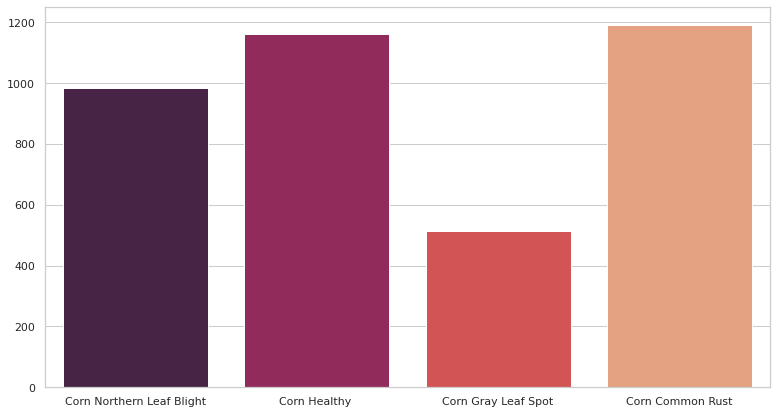

In [4]:
sns.set_theme(style="whitegrid")
Data_imbalance = []
for folder in os.listdir(directory):
    files = gb.glob(pathname=str(directory + "/" + folder +"/*.*"))
    Data_imbalance.append(len(files))
plt.figure(figsize=(13,7))
sns.barplot(x=["Corn Northern Leaf Blight","Corn Healthy ","Corn Gray Leaf Spot","Corn Common Rust"], y=Data_imbalance, palette="rocket")
plt.show()

In [5]:
total = 0 
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i] 
    
weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)
weight_for_3 = (1 / Data_imbalance[3]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))
print('Weight for class 3: {:.2f}'.format(weight_for_3))  


Weight for class 0: 0.98
Weight for class 1: 0.83
Weight for class 2: 1.88
Weight for class 3: 0.81


In [6]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomHeight(0.2),
  tf.keras.layers.RandomWidth(0.2),
])

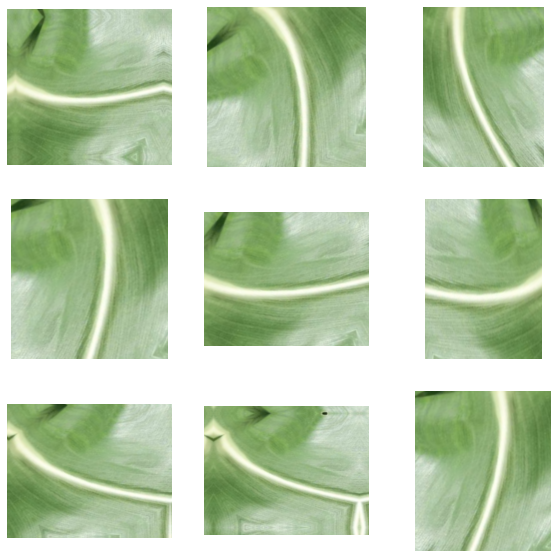

In [7]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

## Corn Common Rust <br>
#### The cause of the disease :

This disease is caused by the fungus Puccinia sorghi. This fungus lives in alternate hosts (a type of Euphorbia plant) and releases its spores during the spring. Its spores can be transmitted over long distances by wind and rain. The infection process begins when the fungus falls on the leaves. Secondary infection can occur from one plant to another due to wind and rain. Favorable conditions for the development of the disease are high relative humidity (about 100%), dew, rain and cold temperatures between 15 and 20 ° C (which may vary depending on the region). Hot and dry weather will in turn slow down or impede the growth of fungi and the occurrence of this disease. It is a problem in plants used to produce seeds and sweet corn. Plants grown as fodder for livestock, for industrial products, or for making processed foods are not affected. But the yield is reduced due to low plant productivity and dormancy.
<br>
#### Symptoms :
Symptoms of the disease appear in the form of fine speckling on both sides of the leaves which slowly develop into small dark and slightly prominent spots. These mainly elongated spots later turn into golden brown pustules irregularly spread in spots on the upper and lower sides. Its color can change to black with the growth of the plant. In contrast to other rust diseases such as: stems, leaves, sheaths and scales. However, the stems grow weak and soft and are more prone to falling. Younger leaf tissues are more susceptible to fungal infection than fully developed leaves. Infected plants during the early stages can show yellowing due to the lack of chlorophyll in the leaves and die. This leads to losses if the upper leaves are affected.
<br>
#### Control and preventive measures :
* Cultivation of disease-resistant varieties.
* And plant early to avoid optimal conditions for infection.
* You should use varieties that mature quickly and in a shorter period.
* Monitor your crop regularly for signs of disease, and intensify monitoring during cloudy weather.
* You must also ensure a balanced fertilization with nitrogen application. 6.Moderation in nitrogen fertilization because * its increase leads to an increase in the incidence of disease, with interest in potassium fertilization.
* Crop rotation with non-susceptible crops. 8.It was possible to treat this disease by using systemic fungicides such as *Saprol Ondar when the infection appeared. 9.Reducing moisture around plants by moderating irrigation and increasing planting distances


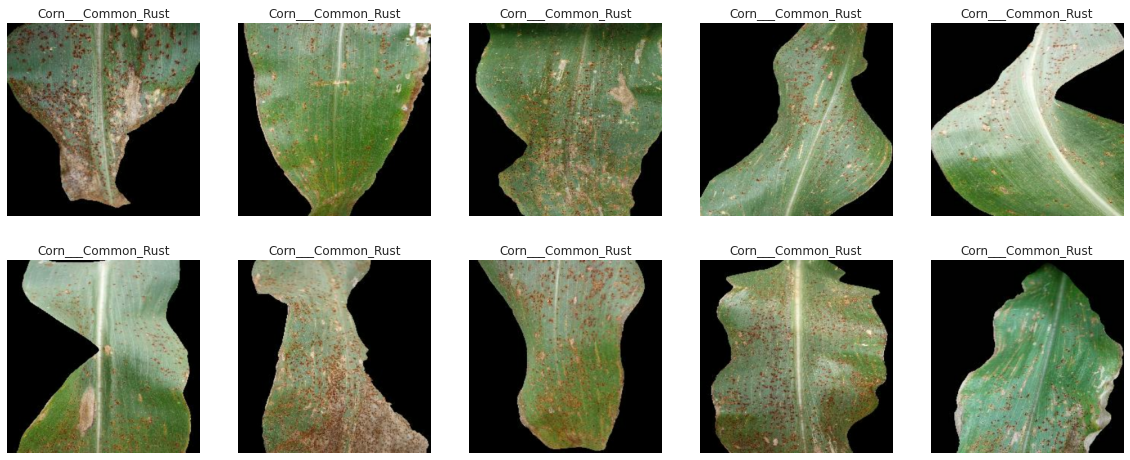

In [8]:
plt.figure(figsize=(20,8))
Common_Rust = []
Gray_Leaf_Spot = []
Corn_Northern_Leaf_Blight =[]
for images , labels in train_dataset.take(1):
    for i in range(100):
        if class_names[labels[i]] == "Corn___Common_Rust":
            Common_Rust.append(images[i].numpy().astype("uint8"))
        if  class_names[labels[i]] == "Corn___Gray_Leaf_Spot":   
            Gray_Leaf_Spot.append(images[i].numpy().astype("uint8"))
        if  class_names[labels[i]] == "Corn___Northern_Leaf_Blight":   
            Corn_Northern_Leaf_Blight.append(images[i].numpy().astype("uint8"))  
for i in range(10):            
    plt.subplot(2,5,i+1)
    plt.imshow(Common_Rust[i])
    plt.axis("off")
    plt.title("Corn___Common_Rust")

## Corn Gray Leaf Spot


#### About it

Gray leaf spot (GLS) is a fungal leaf disease of maize, also known as maize. GLS is considered as one of the most important diseases that limit the productivity of maize worldwide There are two types of fungal pathogens that cause GLS: Cercospora zeae-maydis and Cercospora zeina.
Symptoms of maize include leaf blight, discoloration (greenness) and leaf blight. The characteristic symptoms of GLS are oblong, brown to grayish necrotic lesions running parallel to the leaf, extending between the secondary leaf veins. The fungus lives in topsoil debris and infects healthy crops via asexual spores called conidia. Environmental conditions best suited to infection and growth include moist, humid, and warm climates.<br>
Poor airflow, low sunlight, overcrowding, improper soil nutrients and irrigation management, and poor soil drainage can all contribute to disease spread. Management techniques include crop resistance, crop rotation, residue management, use of fungicides, and weed control. The purpose of disease management is to prevent the amount of secondary disease cycles as well as protect the leaf area from damage prior to grain formation.<br>
Corn gray leaf spot is an important disease in corn production in the United States, and is of economic importance throughout the Midwest and Mid-Atlantic regions. However, it is also widespread in Africa, Central America, China, Europe, India, Mexico, the Philippines, northern South America, and Southeast Asia. The teleomorph (sexual stage) of Cercospora zeae-maydis is postulated to be Mycosphaerella sp. 
<br>

#### The way the disease develops
It is the production of a phytotoxin called Cercospora zeae-maydis one of the reasons for the pathogenic success of inactive cercosporin.All members of the genus Cercospora produce this light-activated toxin during infection. In the absence of light, cercosporin is inactive, but when light is present, the toxin is converted to its excited triplet state.<br>
Activated cercosporin reacts with oxygen molecules, generating active single oxygen radicals.Oxygen radicals interact with plant cell lipids, proteins, and nucleic acids, damaging and killing infected cells, and nutrients released during cell rupture and death that feed Cercospora.<br>
A study on a mutant Cercospora that lacks the gene responsible for cercosporin production showed that although it is not essential for infection, cercosporin increases the virulence of Cercospora fungi.
<br>
#### Control methods
fungicides Fungicides, if sprayed early in the season before initial spoilage, can be effective in reducing disease. There are currently 5 known fungicides that treat gray corn leaf spot.<br>
resistant varieties The most efficient and economical way to reduce yield losses from maize gray leaf spot is the introduction of resistant plant species. In places where leaf spot appears, these crops can eventually grow and remain disease resistant.<br>
Although the disease is not completely eradicated and resistant varieties show symptoms of disease, at the end of the growing season, the disease is not effective in reducing crop yield. SC 407 is a popular corn variety proven to be resistant to gray leaf spot.If gray leaf spot infestation is high, this variety may require the use of a fungicide to achieve full potential.Sensitive cultivars should not be planted in previously infected areas (see § High risk table).


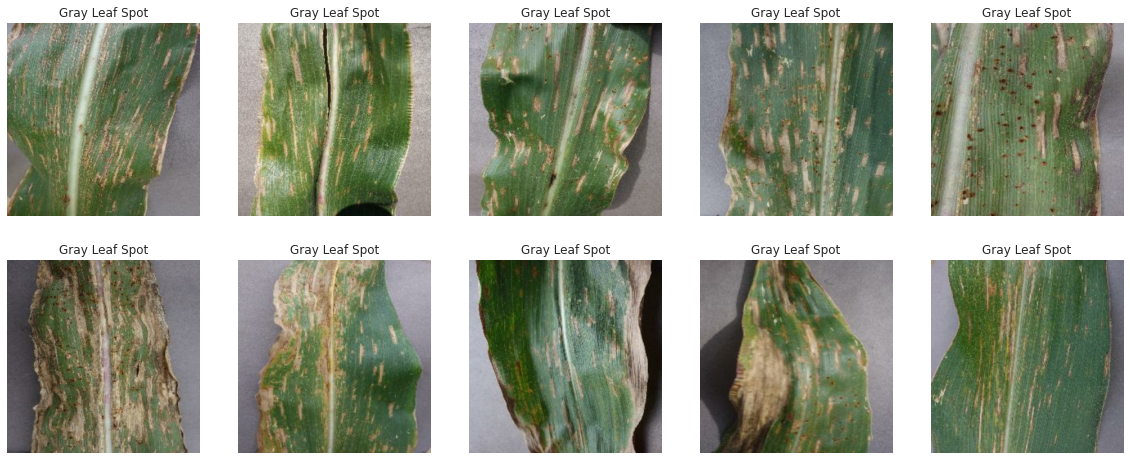

In [9]:
plt.figure(figsize=(20,8))
for i in range(10):            
    plt.subplot(2,5,i+1)
    plt.imshow(Gray_Leaf_Spot[i])
    plt.axis("off")
    plt.title("Gray Leaf Spot")

# Corn Northern Leaf Blight


#### About it
The fungus Exserohilum turcicum (formerly Helminthosporium turcicum) is the causative agent of northern maize leaf blight in southern maize. The symptoms of the disease are the grayish green to dark oblong lesions that appear on the leaves and the huge crop losses caused by this disease in the corn fields at the present time. Where the infection gradually expands throughout the leaf and is not limited to the leaf veins. Wet, rainy, windy, and warm weather are favorable conditions for the growth and spread of the disease in cornfields.
<br>
#### Symptoms
Symptoms appear on the leaves in the form of longitudinal spindle-shaped spots that are small in size at first, greenish-gray in color, then they grow with the progression of the infection and may reach in an area of more than (20 cm in length and 3 cm in width). It turns light brown. The spots are seen on the lower leaves first about 40 days after planting and then spread on the upper leaves with time. In severe infections, the spots permeate most of the surface area of the leaves and fuse with each other, which leads to the drying of the leaves completely and thus the death of the plants.
<br>
#### Control and preventive measures
* Early planting before mid-June so that plants in the vegetative growth stage are not exposed to the appropriate conditions for the spread of the disease.
* When the disease spreads, the affected leaves are collected and burned. In severe infestations, we use appropriate fungicides such as (propiconazole - azoxystrobin - pyraclostrobin).
* You have to plant varieties that are resistant or tolerant to the disease.
* Ensure the abundance of balanced nutrients, avoid excessive nitrogen fertilization, and regularly remove weeds from the field and surrounding area.
* Rotate the plantings with soybeans, beans or sunflowers to avoid the widespread spread of the disease, and use a deep plow to bury plant debris and reduce the amount of pollen in the soil.

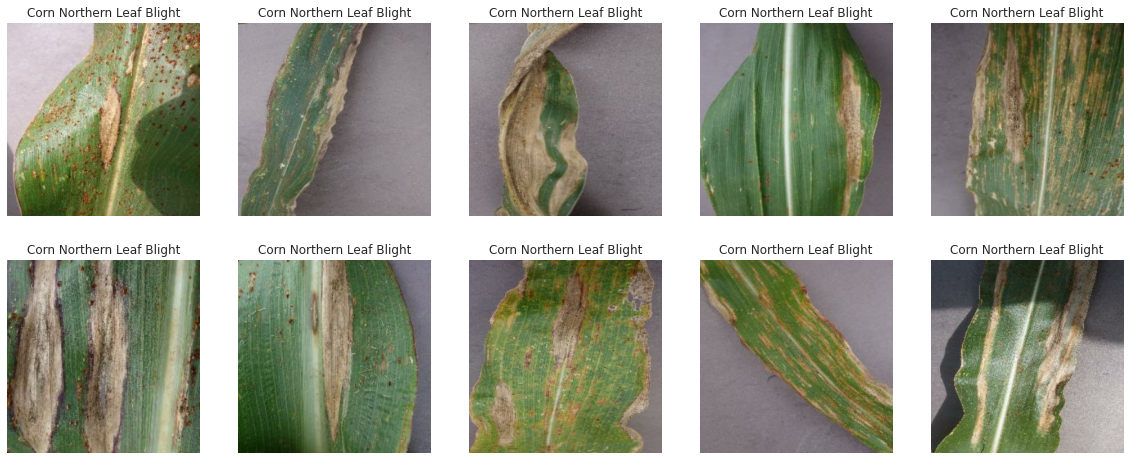

In [10]:
plt.figure(figsize=(20,8))
for i in range(10):            
    plt.subplot(2,5,i+1)
    plt.imshow(Corn_Northern_Leaf_Blight[i])
    plt.axis("off")
    plt.title("Corn Northern Leaf Blight")

In [11]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

# Modeling


### Preparing the ground <a id="3.1"></a>
​
Before we move on to building the models, I will explain the major building blocks in pretrained CV models. Every major ImageNet model has a different architecture, but each one has the common building blocks: **Conv2D, MaxPool, ReLU**. I have already explained the mechanism behind convolution in the previous section, so I will now explain MaxPool and ReLU.
<br></br>
### Pooling Layer
​
<center><img src="https://miro.medium.com/max/792/1*uoWYsCV5vBU8SHFPAPao-w.gif" width="400px"></center>
<br></br>
Similar to the Convolutional Layer, the Pooling layer is responsible for reducing the spatial size of the Convolved Feature. This is to decrease the computational power required to process the data through dimensionality reduction. Furthermore, it is useful for extracting dominant features which are rotational and positional invariant, thus maintaining the process of effectively training of the model <br></br>


There are two types of Pooling: Max Pooling and Average Pooling. Max Pooling returns the maximum value from the portion of the image covered by the Kernel. On the other hand, Average Pooling returns the average of all the values from the portion of the image covered by the Kernel.


Max Pooling also performs as a Noise Suppressant. It discards the noisy activations altogether and also performs de-noising along with dimensionality reduction. On the other hand, Average Pooling simply performs dimensionality reduction as a noise suppressing mechanism. Hence, we can say that Max Pooling performs a lot better than Average Pooling.

​
<center><img src="https://miro.medium.com/max/1192/1*KQIEqhxzICU7thjaQBfPBQ.png" width="400px"></center>
<br></br>

### Convolutional layer:

The main objective of convolution is to extract features such as edges, colours, corners from the input. As we go deeper inside the network, the network starts identifying more complex features such as shapes,digits, face parts as well.
<center><img src="https://miro.medium.com/max/1052/1*Fp7EhLmTtPxJTjmjy_DspQ.gif" width="400px"></center>

### Relu 

ReLU is the most commonly used activation function in neural networks, especially in CNNs. If you are unsure what activation function to use in your network, ReLU is usually a good first choice.

ReLU stands for rectified linear unit, and is a type of activation function. Mathematically, it is defined as y = max(0, x). Visually, it looks like the following:
<center><img src="https://miro.medium.com/max/1400/1*DfMRHwxY1gyyDmrIAd-gjQ.png" width="400px"></center>


In [12]:
IMG_SHAPE = IMG_SIZE +(3,)
base_model = tf.keras.applications.InceptionV3(input_shape=IMG_SHAPE, include_top= False,weights='imagenet')

87924736/87910968 [==============================] - 2s 0us/step


In [13]:
type(base_model)
preprocess_input = tf.keras.applications.inception_v3.preprocess_input

In [14]:
nb_layers = len(base_model.layers)
print("Numbers of Layers =" , nb_layers)
print(base_model.layers[nb_layers - 2].name)  # pre- Last name
print(base_model.layers[nb_layers - 1].name) 

Numbers of Layers = 311
activation_93
mixed10


In [15]:
# iterate over first batch (32 image) in trainset 
image_batch, label_batch = next(iter(train_dataset))  # 32 image arrays
feature_batch = base_model(image_batch)  # run the model on those 32 image (base model with its 1000 causes classification)
print(feature_batch.shape)  # 32 for number of images in this batch and 1000 for classes

(128, 8, 8, 2048)


# Inception v3 (2015)
Inception v3 mainly focuses on burning less computational power by modifying the previous Inception architectures. This idea was proposed in the paper Rethinking the Inception Architecture for Computer Vision, published in 2015. It was co-authored by Christian Szegedy, Vincent Vanhoucke, Sergey Ioffe, and Jonathon Shlens.

In comparison to VGGNet, Inception Networks (GoogLeNet/Inception v1) have proved to be more computationally efficient, both in terms of the number of parameters generated by the network and the economical cost incurred (memory and other resources).

If any changes are to be made to an Inception Network, care needs to be taken to make sure that the computational advantages aren’t lost.
Thus, the adaptation of an Inception network for different use cases turns out to be a problem due to the uncertainty of the new network’s efficiency. In an Inception v3 model, several techniques for optimizing the network have been put suggested to loosen the constraints for easier model adaptation. The techniques include factorized convolutions, regularization, dimension reduction, and parallelized computations.


<br>
<center> <img   width="800"  src="https://lh3.googleusercontent.com/bA_Rkj4a0sA3NZ1wjUYIO5_eq0hUmiBNbagOFb84C8Y9GxeedGUYNd-LIbhAlpW-1o8xSeNypMnbD6p-XsrAQvup3FeWXrAoZig7l7Y9WIK3uDHooEMEKiNNQ2qt0PfA4Zfsyltn" alt="Alternative text" /> </center>

In [16]:
def plant_leaf_model( image_shape=IMG_SIZE):
    ''' Define a tf.keras model for multi-class classification out of the InceptionV3 model '''
    image_shape = image_shape + (3,)
    
    resnet_model = tf.keras.applications.InceptionV3(input_shape=IMG_SHAPE, include_top= False,weights='imagenet')
    resnet_model.trainable = True
    for layer in resnet_model.layers[0 : 291]:
        layer.trainable = False
    
    inputs = tf.keras.Input(image_shape)
    x = data_augmentation(inputs)
    x = preprocess_input(inputs)
    x = resnet_model(x , training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    prediction_layer = tf.keras.layers.Dense(4 ,activation = "softmax") 
    outputs = prediction_layer(x)
    model = tf.keras.Model(inputs, outputs) 
    model.summary()
    return model

In [17]:
Plant_Leaf_Model = plant_leaf_model(IMG_SIZE)

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 299, 299, 3)]     0         
_________________________________________________________________
tf.math.truediv (TFOpLambda) (None, 299, 299, 3)       0         
_________________________________________________________________
tf.math.subtract (TFOpLambda (None, 299, 299, 3)       0         
_________________________________________________________________
inception_v3 (Functional)    (None, 8, 8, 2048)        21802784  
_________________________________________________________________
global_average_pooling2d (Gl (None, 2048)              0         
_________________________________________________________________
dropout (Dropout)            (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 4)                 8196  

# Compiling the model 
Following this, you have to compile our model. You need to use an Adam optimizer to optimize your model and a loss function to calculate the loss. The metrics define which metric you want to calculate. In this case, it is accuracy.

In [18]:
base_learning_rate = 0.001
Plant_Leaf_Model.compile(optimizer=tf.keras.optimizers.Nadam(learning_rate=base_learning_rate),
                           loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                           metrics=['accuracy'])

# Training our model
After compiling, fit the model to your training data, ie: train the model. You will train it in batch sizes of 128 with 10 epochs and use 20% of the data as the validation set.

In [19]:
history = Plant_Leaf_Model.fit(train_dataset , verbose=2 , epochs=10 ,class_weight=class_weight,
                               validation_data=validation_dataset , use_multiprocessing= True)


Epoch 1/10
28/28 - 355s - loss: 0.6484 - accuracy: 0.8278 - val_loss: 0.1499 - val_accuracy: 0.9481
Epoch 2/10
28/28 - 342s - loss: 0.1078 - accuracy: 0.9507 - val_loss: 0.1143 - val_accuracy: 0.9584
Epoch 3/10
28/28 - 347s - loss: 0.0692 - accuracy: 0.9671 - val_loss: 0.1013 - val_accuracy: 0.9662
Epoch 4/10
28/28 - 343s - loss: 0.0577 - accuracy: 0.9743 - val_loss: 0.1356 - val_accuracy: 0.9532
Epoch 5/10
28/28 - 341s - loss: 0.0493 - accuracy: 0.9781 - val_loss: 1.1193 - val_accuracy: 0.7325
Epoch 6/10
28/28 - 340s - loss: 0.0758 - accuracy: 0.9735 - val_loss: 0.0884 - val_accuracy: 0.9688
Epoch 7/10
28/28 - 342s - loss: 0.0275 - accuracy: 0.9896 - val_loss: 0.0755 - val_accuracy: 0.9740
Epoch 8/10
28/28 - 340s - loss: 0.0171 - accuracy: 0.9951 - val_loss: 0.1677 - val_accuracy: 0.9247
Epoch 9/10
28/28 - 341s - loss: 0.0136 - accuracy: 0.9977 - val_loss: 0.1158 - val_accuracy: 0.9610
Epoch 10/10
28/28 - 341s - loss: 0.0738 - accuracy: 0.9712 - val_loss: 0.0763 - val_accuracy: 0.9740

In [20]:
Plant_Leaf_Model.evaluate(validation_dataset , verbose = 1)

4/4 [==============================] - 33s 7s/step - loss: 0.0763 - accuracy: 0.9740


[0.07625966519117355, 0.9740259647369385]

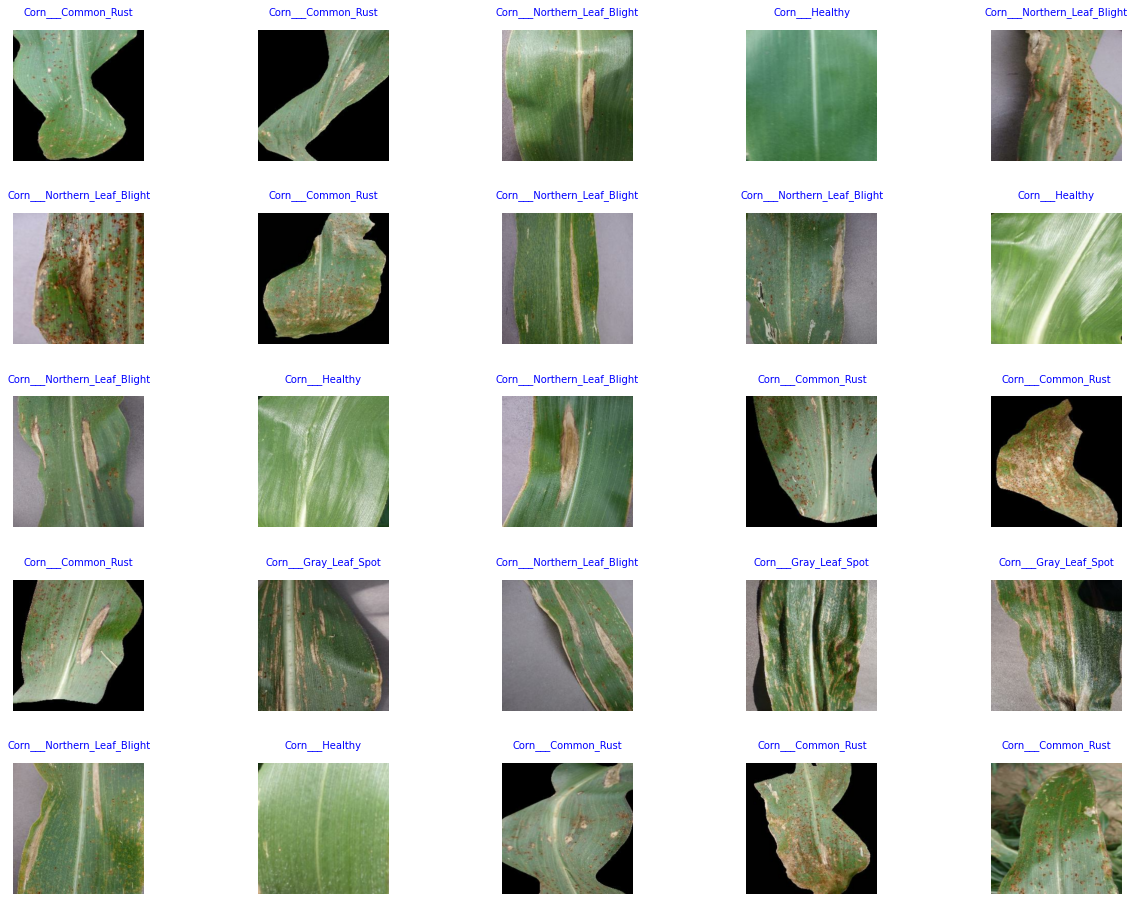

In [21]:
plt.figure(figsize=(20, 15))
for images, labels in train_dataset.take(1):
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
        im2 = images[i].numpy().astype("uint8")
        img2 = tf.expand_dims(im2, 0)
        predict = Plant_Leaf_Model.predict(img2)
        predicted= class_names[np.argmax(predict)]
        actual = class_names [labels[i].numpy().astype("uint8")]
        if (actual == predicted):
            plt.title(predicted, fontsize=10, color= 'blue', pad=15);
        else :
            plt.title(actual, fontsize=10, color= 'red' ,pad=15);  
        plt.subplots_adjust(left=0.1,bottom=0.1, right=0.9, 
                            top=0.9, wspace=0.4,hspace=0.4)    

# Plotting Accuracy

A convolutional neural network can be evaluated using the ‘evaluate’ method. This method takes the test data as its parameters. Before this, the data is plotted on the console using ‘matplotlib’ library and ‘imshow’ methods.

Convolutional neural networks have been used to produce great results for a specific kind of problems, such as image recognition.  

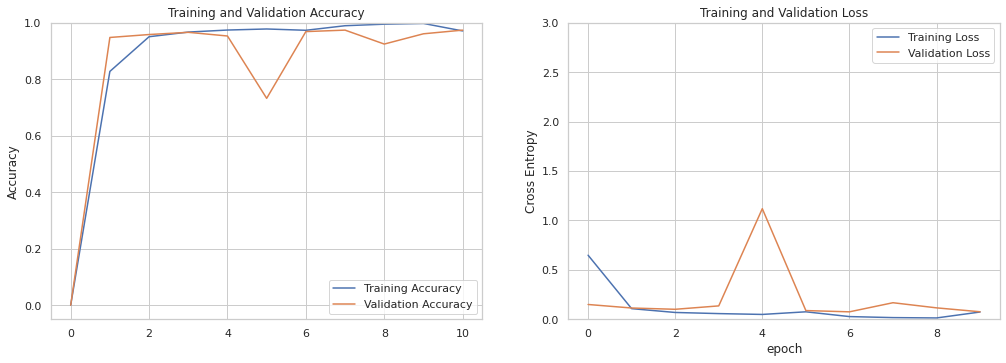

In [22]:
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(17, 12))
plt.subplot(2, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,3.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()